<a href="https://colab.research.google.com/github/Riana-PSB/Assignment-1/blob/CNN-Model/cnn_v3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook, we will be creating a CNN (Convolutional Neural Network) based classifier for the classification of CIFAR-10 dataset.

**About the dataset**

CIFAR-10 dataset is a subset of CIFAR-100 having 80 million images of 100 different objects. CIFAR-10 takes 60,000 images for 10 classes from the original dataset in which 50,000 images are for training and 10,000 images are for testing.

The classes in the dataset are -
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


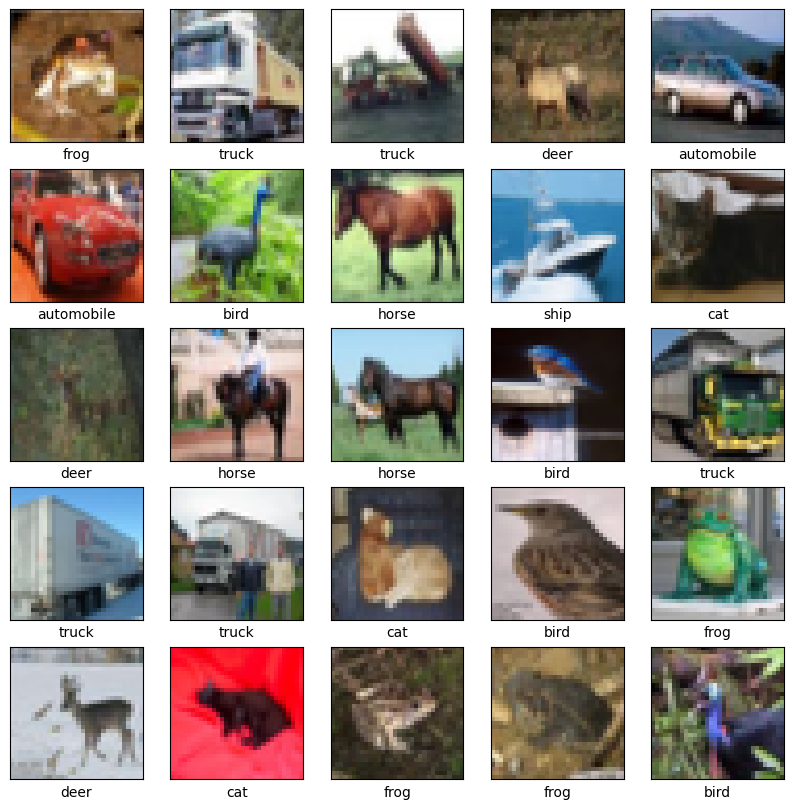

In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Creating a CNN model**

We are going to create a CNN based classification model using *keras* module.

In [3]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer='sgd',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.2460 - loss: 2.0622 - val_accuracy: 0.2664 - val_loss: 1.9779
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.3958 - loss: 1.6732 - val_accuracy: 0.4412 - val_loss: 1.5379
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.4719 - loss: 1.4694 - val_accuracy: 0.4781 - val_loss: 1.4561
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.5153 - loss: 1.3597 - val_accuracy: 0.5352 - val_loss: 1.3042
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5474 - loss: 1.2784 - val_accuracy: 0.5339 - val_loss: 1.3064
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5732 - loss: 1.2026 - val_accuracy: 0.5696 - val_loss: 1.2125
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.5952 - loss: 1.1411 - val_accuracy: 0.5606 - val_loss: 1.2270
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6198 -

313/313 - 4s - 12ms/step - accuracy: 0.6054 - loss: 1.1451


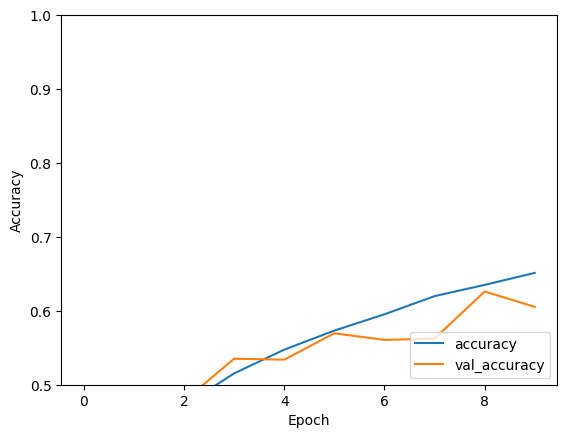

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [7]:
print(test_acc)

0.605400025844574


In [8]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.6275 - loss: 1.0569 - val_accuracy: 0.6243 - val_loss: 1.0722
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6806 - loss: 0.9100 - val_accuracy: 0.6733 - val_loss: 0.9396
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7204 - loss: 0.8003 - val_accuracy: 0.6994 - val_loss: 0.8738
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7524 - loss: 0.7067 - val_accuracy: 0.6968 - val_loss: 0.8872
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7781 - loss: 0.6347 - val_accuracy: 0.7049 - val_loss: 0.8784
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 50ms/step - accuracy: 0.7992 - loss: 0.5699 - val_accuracy: 0.6941 - val_loss: 0.9766
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.8182 - loss: 0.5119 - val_accuracy: 0.6858 - val_loss: 0.9945
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.8407 -

313/313 - 5s - 17ms/step - accuracy: 0.6973 - loss: 1.0877


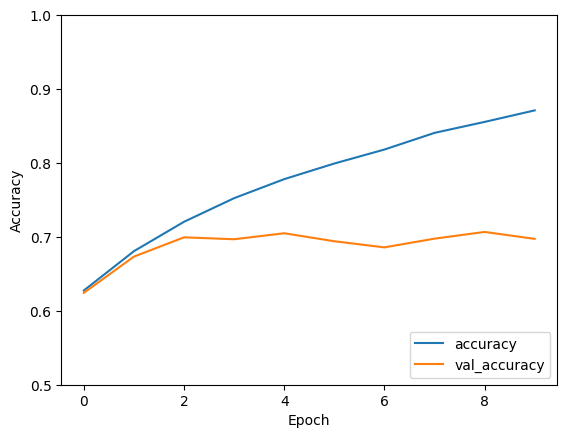

In [9]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [10]:
print(test_acc)

0.6973000168800354


In [11]:
# save model
model.save('final_model.keras')

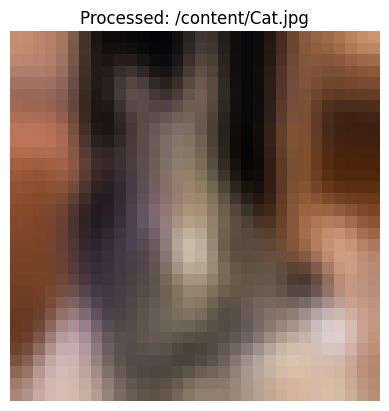

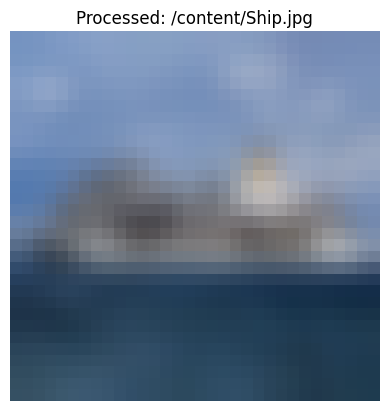

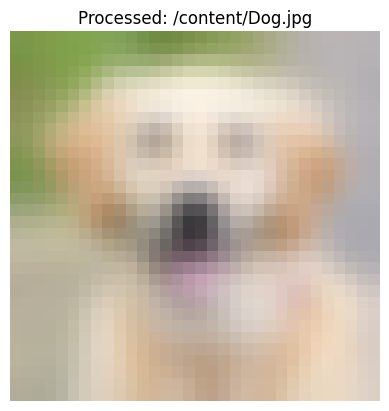

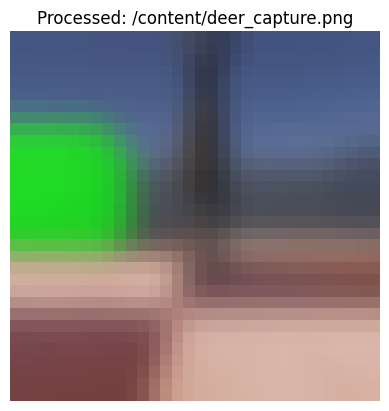

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Accuracy: 25.00%
/content/Cat.jpg → cat (10.25% confidence)
Accuracy: 50.00%
/content/Ship.jpg → ship (9.73% confidence)
Accuracy: 75.00%
/content/Dog.jpg → dog (6.29% confidence)
Accuracy: 100.00%
/content/deer_capture.png → deer (3.15% confidence)


In [14]:
from tensorflow.keras import preprocessing, models
import numpy as np
import cv2
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# --- Load + preprocess image ---
def load_image(filename):
    img = preprocessing.image.load_img(filename)
    img = preprocessing.image.img_to_array(img)

    # Resize FIRST
    img = cv2.resize(img, (32, 32))

    # Stronger blur (important!)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    # Reduce detail further (simulate CIFAR)
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Normalize
    img = img.astype('float32') / 255.0

    return img

# --- Run predictions on multiple images ---
def run_multiple():
    img_paths = [
        "/content/Cat.jpg",
        "/content/Ship.jpg",
        "/content/Dog.jpg",
        "/content/deer_capture.png"
    ]

    model = models.load_model('final_model.keras')

    processed_images = []

    for path in img_paths:
        try:
            img = load_image(path)
            processed_images.append(img)

            # 🔥 SHOW processed image
            plt.imshow(img)
            plt.title(f"Processed: {path}")
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"Error loading {path}: {e}")

    processed_images = np.array(processed_images)

    predictions = model.predict(processed_images)

    true_labels = ['cat', 'ship', 'dog', 'deer']

    correct = 0
    # Print results
    for i, pred in enumerate(predictions):
        result = np.argmax(pred)
        confidence = np.max(pred)
        predicted_label = class_names[result]

        if predicted_label == true_labels[i]:
          correct += 1

        accuracy = correct / len(true_labels)
        print(f"Accuracy: {accuracy * 100:.2f}%")

        print(f"{img_paths[i]} → {class_names[result]} ({confidence:.2f}% confidence)")

# Run
run_multiple()